# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *

# frank1d
from frank.utilities import UVDataBinner

# Data

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}

In [6]:
data = AS209

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
r_out = data['rout']

In [7]:
# Frank Parameters
N = 300
 # load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

# Run F2D

In [8]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, r_out, geom)

In [9]:
frank2d.process_vis(u, v, Vis, Weights)

Enforcing Hermitian symmetry...
Setting gridded data...


/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/frank2d/preprocess_vis.py:136: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_gridded_matrix


In [10]:
# Let's review the input for frank2d.

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_17668/1130263636.py:9: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


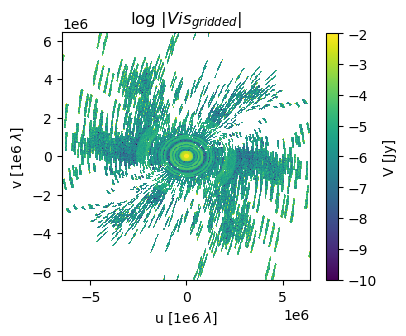

In [11]:
input =  frank2d.gridded_data
u_g, v_g, vis_g, weights_g = input["u"], input["v"], input["vis"], input["weights"]
u_shifted, v_shifted = np.fft.fftshift(u_g.reshape(N, N)), np.fft.fftshift(v_g.reshape(N, N))
vis_shifted = np.fft.fftshift(vis_g.reshape(N, N))

plt.figure(figsize= (4, 4))
plt.pcolormesh(v_shifted,
               u_shifted,
               np.log(np.abs(vis_shifted)),
               cmap="viridis", vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{gridded}$|')
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'V [Jy]', size=10)
plt.gca().set_aspect(1)
plt.show()

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time = 0.78  min |  46.98 seconds
Solving linear system...
         * rtol: 1e-09
         * final tolerance: 0.2881751982790493
Final tolerance :  0.2881751982790493
.... iteration:  0
                        -> actual tol:  288175198.2790493 vs  0.2881751982790493
.... iteration:  1
                        -> actual tol:  33828640.973787524 vs  0.2881751982790493
.... iteration:  2
                        -> actual tol:  37685844.19145373 vs  0.2881751982790493
.... iteration:  3
                        -> actual tol:  62636050.13945073 vs  0.2881751982790493
.... iteration:  4
                        -> actual tol:  16954480.814089693 vs  0.2881751982790493
.... iteration:  5
                        -> actual tol:  14028715.442545647 vs  0.2881751982790493
.... iteration:  6
                        -> actual tol:  12324830.099502323 vs  0.2881751982790493
.... iteration:  7
                        -> actual tol:  891

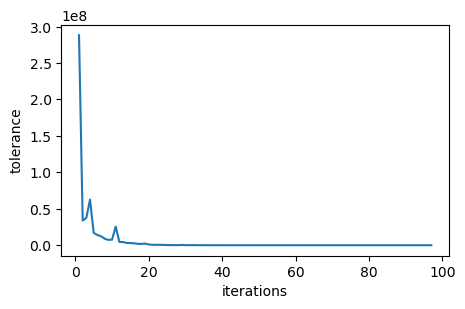

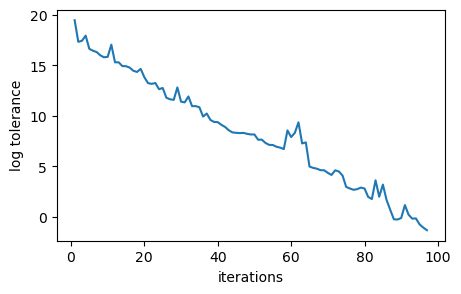

--> time = 0.03  min |  1.95 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...
F2D model in 2.57 minutes.


In [12]:
start_time = time.time()
frank2d.fit()
end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes.")

# Plot

In [13]:
import matplotlib.colors as colors

In [15]:
class Plot(object):
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._Geometry = Geometry
        self._u_gridded, self._v_gridded = self._frank2d._gridded_data['u'], self._frank2d._gridded_data['v']
        self._vis_gridded, self._weights_gridded = self._frank2d._gridded_data['vis'], self._frank2d._gridded_data['weights']
        self._Nx = self._Ny = Frank2D._N

        
    def intensity_model(self, title="Frank2D intensity model", fig_size = 6, vmin = 0, vmax = 1e11, lim = 2):
        frank2d = self._frank2d

        I = frank2d.sol_intensity

        x_ = frank2d._FT._Xn * rad_to_arcsec
        y_ = frank2d._FT._Yn * rad_to_arcsec
        Nx, Ny = self._Nx, self._Ny
        x, y = x_, y_

        if deproject:
            # Deprojection.
            inc_r = self._Geometry._inc * deg_to_rad
            pa_r = self._Geometry._pa * deg_to_rad
    
            cos_i = np.cos(inc_r)
            cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
            x = (x_ * cos_pa + y_ * sin_pa)/ cos_i
            y = (x_ * -sin_pa + y_ * cos_pa)

        plt.figure(figsize=(fig_size, fig_size))

        X = x.reshape(Ny, Nx)
        Y = y.reshape(Ny, Nx)
        I = I.reshape(Ny, Nx)

        I_flip = np.fliplr(I)
        X_flip = -np.fliplr(X)

        norm = colors.PowerNorm(gamma=0.45, vmin=vmin, vmax=vmax)
        plot = plt.pcolormesh(X_flip, Y, I_flip,
                              cmap='magma',norm=norm)

        cmap = plt.colorbar(plot, shrink=0.8)
        cmap.set_label(r' $I_{\nu}$ [Jy $sr^{-1}$]', size=10)

        plt.title(title)
        plt.xlabel(r'$\Delta\alpha$ ["]')
        plt.ylabel(r'$\Delta\delta$ ["]')

        plt.gca().set_aspect(1)  


        plt.xlim(lim, -lim)
        plt.ylim(-lim, lim)

        xticks = np.linspace(lim, -lim, 5)
        yticks = np.linspace(-lim, lim, 5)
        plt.xticks(xticks)
        plt.yticks(yticks)

        plt.show()

    def given_intensity_model(self, I, N, x, y, title="", fig_size = 6, vmax = 4e10):
        frank2d = self._frank2d
    
        plt.figure(figsize=(fig_size, fig_size))

        X = x.reshape(N, N)
        Y = y.reshape(N, N)
        I = I.reshape(N, N)

        X_flip = -np.fliplr(X)


        norm = colors.PowerNorm(gamma=0.45)
        plot = plt.pcolormesh(X_flip, Y, I,
                              cmap='magma',norm=norm)

        cmap = plt.colorbar(plot, shrink=0.8)
        cmap.set_label(r'I [Jy $sr^{-1}$]', size=10)

        plt.title(title)
        plt.xlabel("dRa ['']")
        plt.ylabel("dDec ['']")

        plt.gca().set_aspect(1)  

        plt.xlim(2, -2)
        plt.ylim(-2, 2)

        plt.show()

    def visibility_model(self, title=r'$log |Vis_{Model}|$', fig_size = 6, deproject = False):
        
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny

        vis_model = frank2d.sol_visibility.reshape(Nx, Ny)
        
        u, v = frank2d._FT._Un, frank2d._FT._Vn

        u_shifted, v_shifted = np.fft.fftshift(u.reshape(Nx, Ny)), np.fft.fftshift(v.reshape(Nx, Ny))
        vis_shifted = np.fft.fftshift(vis_model)

        if deproject: 
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

        plt.figure(figsize = (fig_size, fig_size))
        plt.pcolormesh(v_shifted,
                       u_shifted,
                       np.log(np.abs(vis_shifted)),
                       cmap="viridis", vmin=-12, vmax=-2)
        plt.xlabel(r'u [ $\lambda$]')
        plt.ylabel(r'v [ $\lambda$]')
        plt.gca().set_aspect('equal') 
        cmap = plt.colorbar(shrink=0.8)
        cmap.set_label(r'V [Jy]', size=15)
        plt.title(r'log|$Vis_{model}$|')
        plt.show()


    def visibility_gridded_input(self, title=r'$log |Vis_{gridded input}|$', deproject = False):
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
        
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded, weights_gridded = self._vis_gridded, self._weights_gridded
        
        u_shifted, v_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny)), np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        vis_shifted = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))

        if deproject: 
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

        
        plt.pcolormesh(v_shifted,
                       u_shifted,
                       np.log(np.abs(vis_shifted)),
                       cmap="viridis", vmin=-12, vmax=-2)
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(r'log |$Vis_{Input}$|')
        cmap = plt.colorbar()
        cmap.set_label(r'V [Jy]', size=12)
        
    def  get_vis_profile(self, n_bins, range =  None, weighted = False, deprojected = False):
            u = self._frank2d._FT._Un
            v = self._frank2d._FT._Vn
        
            inc_r = self._frank2d._Geometry._inc*deg_to_rad
            pa_r = self._frank2d._Geometry._pa*deg_to_rad
    
            if deprojected:
                cos_i = np.cos(inc_r)
                cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
            
                u_ = u * cos_pa - v * sin_pa
                v_d = u * sin_pa + v * cos_pa
                u_d = u_ * cos_i
                u, v = u_d, v_d
            
            q = np.hypot(u, v)
            
            Vis = self._frank2d.sol_visibility
            q = q.flatten()
            Vis = Vis.flatten()
            
            weights_gridded = self._frank2d._gridded_data['weights']
            Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
            q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            if weighted:
                if range is None:
                    Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
                    Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
                else:
                    Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
                    Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
                    
                Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
                return q_centers, Vis_Weights_binned/Weights_binned
        
            return q_centers, Vis_binned
            
    def frank1d(self, u, v, Vis, Weights, alpha = 1.3, w_smooth = 1e-3, n_pts = 300):
        Rout = self._frank2d._Rmax*rad_to_arcsec
        geom = self._Geometry
        inc, pa, dra, ddec = geom._inc, geom._pa, geom._dra, geom._ddec
        
        geom_f1d = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
        FF = FrankFitter(Rout, n_pts, geom_f1d, alpha = alpha, weights_smooth = w_smooth)
        sol = FF.fit(u, v, Vis, Weights)
        return sol
        
    def compare_vis_profile_frank1d(self, u, v, Vis, Weights):
        #  Plot variables.
        cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
        bin_widths = [1e3, 1e5]

        u_deproj, v_deproj, _ = self._Geometry.deproject(u, v)

        
        baselines = np.hypot(u_deproj, v_deproj)         
        grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                                   np.log10(max(baselines.max(), baselines[-1])),
                                   10**4)
        
        
        plt.figure(figsize=(14,5))
        
        # Raw visibilities -------------------------------------------------------------------
        binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
        plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
                     marker=ms[0], ls='None', 
                     label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
        
        binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
        plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
                     marker=ms[1], ls='None', 
                     label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

        # Frank1D -----------------------------------------------------------------------------
        Nbins = 1000
        sol = self.frank1d(u, v, Vis, Weights)
        baselines_edges = np.geomspace(sol.q[0], sol.q[-1], Nbins + 1 )
        baselines_centers = np.sqrt(baselines_edges[:-1] * baselines_edges[1:]) 
        range = (sol.q[0], sol.q[-1])
        
        vis_fit_1d = sol.predict_deprojected(baselines_centers)
        plt.plot(baselines_centers, np.abs(vis_fit_1d), color = "red", label = r'frank1d', ls ='--')

        # Frank2D (deprojected)------------------------------------------------------------------
        q, Vis_model = self.get_vis_profile(baselines_edges, range, weighted = True, deprojected = True)
        plt.plot(baselines_centers, np.abs(Vis_model), label = f'frank2d', color = 'blue')

        plt.xlabel(r'baseline [$\lambda$]')
        plt.xscale('log')
        plt.yscale('log')
        plt.ylim(1e-5, 10)
        plt.xlim(2e5, 6e6)
        plt.ylabel('|V| [Jy]', size = 10)
        plt.title(r'$Visibility_{Model}$ N = ' + str(self._Nx))
        plt.legend(fontsize= 10, loc = 'best')
        plt.show()

IndentationError: unindent does not match any outer indentation level (<string>, line 185)

In [ ]:
Plot = Plot(frank2d, geom)

In [ ]:
Plot.visibility_model(deproject = True)

In [ ]:
Plot.intensity_model(title = r'$I_{model}$')